In [66]:
import sys
sys.path.insert(1, "../../module")
import numpy as np      
import snflics
from skimage.transform import resize
from netCDF4 import Dataset                             
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt                         
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")

In [67]:
# lat and lon meshgrids
geodata = np.load("../../data/geodata/lat_lon_2268_2080.npz")
lons = geodata["lon"][:]
lats = geodata["lat"][:]

# Dakar lat lon
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [ ]:
# Load data
x0_lat = np.load("../../output/x0-analysis/all_valid_lats.npy")
x0_lon = np.load("../../output/x0-analysis/all_valid_lons.npy")

# fixed random seed for reproducibility
np.random.seed(42)

# Ensure both arrays have the same length
assert len(x0_lat) == len(x0_lon), "Latitude and longitude arrays must be the same length."

sample_size = 1500
indices = np.random.choice(len(x0_lat), size=sample_size, replace=False)

# Subsample
x0_lat_sample = x0_lat[indices]
x0_lon_sample = x0_lon[indices]

Maybe I can do this every year or month, or time of day, 

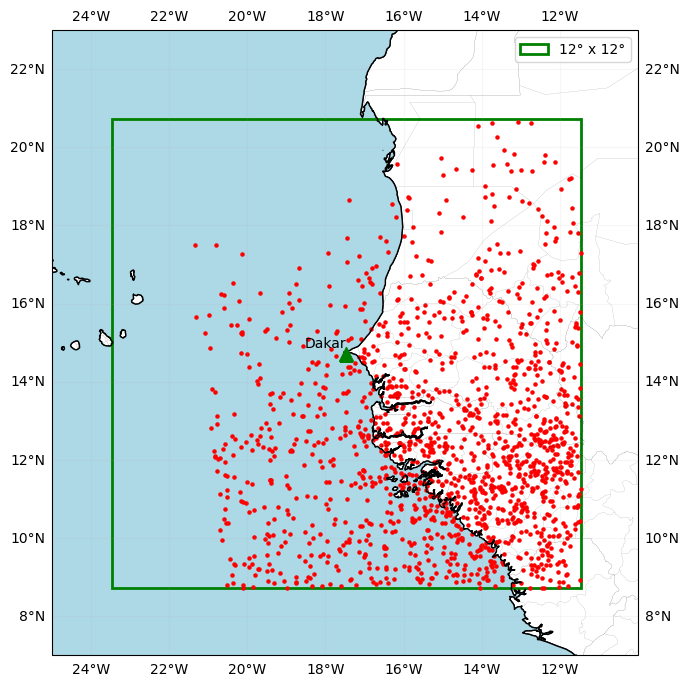

In [70]:
# Define extent
extent = (-25, -10, 7, 23)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)
# ax.text(-14, 15, "Senegal", fontsize=20, fontweight="bold", color="black",
#         transform=ccrs.PlateCarree(), ha="center", va="center", alpha=0.7)

box_sizes = [12]
colors = ['green']
labels = ['12° x 12°']

# Add rectangles
for size, color, label in zip(box_sizes, colors, labels):
    lower_left_lon = Dakar_lon - size / 2
    lower_left_lat = Dakar_lat - size / 2
    rect = Rectangle((lower_left_lon, lower_left_lat), size, size,
                     linewidth=2, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)

plt.scatter(x0_lon_sample, x0_lat_sample, marker=".", color="red", s=20, transform=ccrs.PlateCarree())

# Plot a marker at Dakar's location
plt.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10)
plt.text(Dakar_lon, Dakar_lat+0.1, "Dakar", ha="right", va="bottom")
plt.legend()
plt.tight_layout()
plt.show()